# AI-Powered YouTube Video Transcription and Text Summarization System

## 1. Install the required version of the Hugging Face Transformers library 

In [1]:
!pip install transformers==4.52.4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 74.5 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 30.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 72.0 MB/s eta 0:00:00:00:01
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.11.0
    Uninstalling huggingface_hub-1.11.0:
      Successfully uninstalled huggingface_hub-1.11.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


## 2. Extract YouTube Video Transcript  
`This section extracts the video ID from a YouTube URL and retrieves the available English or Arabic transcript using the YouTubeTranscriptApi library. The extracted transcript is then combined into a single text string for further preprocessing and summarization.`
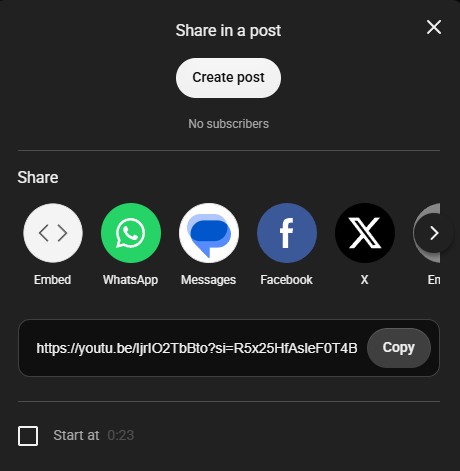

In [2]:
!pip install youtube-transcript-api

from urllib.parse import urlparse, parse_qs
from youtube_transcript_api import YouTubeTranscriptApi


def extract_video_id(url: str) -> str:
    """
    Extract the YouTube video ID from a URL.
    Raises ValueError if no 'v' parameter is found.
    """
    parsed = urlparse(url)
    host = (parsed.hostname or "").lower()
    if host.startswith("www."):
        host = host[4:]

    if host == "youtu.be":
        video_id = parsed.path.lstrip("/").split("/")[0]
        if video_id:
            return video_id

    if host in ("youtube.com", "m.youtube.com", "music.youtube.com"):
        qs = parse_qs(parsed.query)
        if qs.get("v"):
            return qs["v"][0]

        parts = parsed.path.strip("/").split("/")
        if len(parts) >= 2 and parts[0] in ("shorts", "embed", "live", "v"):
            return parts[1]

    raise ValueError(f"No video id found in URL: {url}")


url = "https://youtu.be/IjrIO2TbBto" # <-------------------------------- 'Put The Video Link Here'
video_id = extract_video_id(url)
api = YouTubeTranscriptApi()
fetched = api.fetch(video_id, languages=["en", "ar"])
text = "\n".join(snippet.text for snippet in fetched)
print(text)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.2/485.2 kB 22.9 MB/s eta 0:00:00
Today we're building the world's first
fully remote control Tesla Cybert truck.
>> This is so sick.
>> But it's going to end in disaster.
>> What's going on? What's going on?
>> Oh my gosh.
>> Luckily, this project is for Whistle and
Diesel, so disaster is the goal. This is
going to take some clever robotics,
unexpected challenges, and we're going
to try something crazy.
We're remote driving a Cyber Truck.
The problem is that we only have 3 days
to pull this off. Like, I don't even
have time to order parts. We'll have to
see what's in stock. Okay, we're
gathering parts from all over my
facility.
[music] We definitely need this Arduino.
[music]
We don't have time to hack into the
canvas and electronically control this
thing. It is possible, not easy. So,
we're going to have to put some sort of
motor on the steering wheel.
We're just going to bolt this puppy on
right here. We'll just pull this seat
out and b

## 3. Load the Summarization Model

In [3]:
from transformers import pipeline

summarizer = pipeline("summarization", model="facebook/bart-large-cnn")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


## 4. Text from Video Transcript

In [4]:
text = """Today we're building the world's first
fully remote control Tesla Cybert truck.
>> This is so sick.
>> But it's going to end in disaster.
>> What's going on? What's going on?
>> Oh my gosh.
>> Luckily, this project is for Whistle and
Diesel, so disaster is the goal. This is
going to take some clever robotics,
unexpected challenges, and we're going
to try something crazy.
We're remote driving a Cyber Truck.
The problem is that we only have 3 days
to pull this off. Like, I don't even
have time to order parts. We'll have to
see what's in stock. Okay, we're
gathering parts from all over my
facility.
[music] We definitely need this Arduino.
[music]
We don't have time to hack into the
canvas and electronically control this
thing. It is possible, not easy. So,
we're going to have to put some sort of
motor on the steering wheel.
We're just going to bolt this puppy on
right here. We'll just pull this seat
out and build a frame here that'll hold
everything,
dude.
What is that?
>> What else did you like about that
rental?
>> Aura, stop listening to us. That's so
creepy.
>> What's the emergency?
>> No, there's no No, there is no
emergency.
>> What's going on?
>> In 3 days, you're not going to want to
be inside this vehicle. I'm just saying.
[music]
[music]
>> Got it. messing with me, huh? What's on
your mind?
>> I'm not messing with you.
>> Totally fine. Fire away with whatever's
next.
>> Hey, Ara, can can we remove the front
seat and you'll still drive or are you
going to freak out about it?
>> I'm here whenever you actually want to
chat.
>> I think her ears are plugged up, dude.
[music]
>> All right, let's see if it still drives.
Yep. [laughter]
Still works. Well, that's good news.
Actually, we should take it for a little
drive just to make sure that it doesn't
freak out in like 2 minutes or
something.
I can't see anything.
Navigating by the treetops. That's an
aspen. That's a pineapple.
>> Totally good. There was no speed limiter
or anything that came on with the
driver's seat missing. Let's build a
little frame to hold all of our things.
[music]
Oh yeah, that's looking nice. We'll just
cut out some brackets on the laser
and bolt them on.
>> [music]
>> airbag.
I just need to mount this.
Hm. Before I build a custom bracket,
let's check Amazon and see if they have
one. Tesla Cybertruck steering wheel to
custom gearbox adapter flange. Perfect.
Dude, they don't use that tape.
I'm so glad I didn't have to make that.
>> No way.
>> Yeah, we got lucky.
>> Yes, it's all coming together.
[music]
It's time for some more welding.
I always TIG weld inside of cars because
it doesn't spray sparks everywhere.
And now to mount the servos.
This one's for the gas pedal.
[music]
To get power for our system, we need
actually four different types of
voltage. We need 48 volts for the
stepper motor on the steering, 24 volts
for the other two servo motors, 12 volts
for the relay bank, 5 volts for the
computer logic. We're going to get 48
volts up here, right from the
mid-voltage battery. Reckon if I tap on
right here, we'll be good to go.
Yep. To get the lower voltages, we'll
just put a couple of small transformers
in the cab. This is all looking pretty
good. I just have one problem with the
brake. There's no safety element to it.
So, this is what we're going to do now.
We're going to put an air ram on the
brake that is always pushing and you
release it with the remote control
system. That way, if we lose electronic
power, it pushes the brake and stops the
truck. I tried using the onboard air
from the Cyber Truck, but it's not going
to work cuz the tank doesn't stay full
all the time. So, we're going to put a
compressor in the back seat. There's our
air ram.
So now we have a pneumatic dead man
switch right here. So you have to be
holding this in order to drive the
truck. All other times it puts the brake
on.
Now that the brake is working, I want to
get the steering dialed in. This is
always a tricky part because of how fast
it has to move and how precise it has to
be. So here's where we're at. This is
what I always run into with these
stepper motors. They are just kind of
terrible in every way.
Like it wants to work.
You have to tune them manually in the
Arduino code to make them like work at
all. Really wish I had time to get a
proper servo setup here because it's so
much easier to do and they have way more
power and they're way faster.
It's actually working. Oh my gosh. I was
missing this piece of code. Min pulse
width. That made all the difference,
>> bro.
>> Yeah.
>> This is going to be the funnest RC thing
we've ever done.
>> Can we keep this?
>> I know. So, steering,
gas, brake.
>> Okay, it's [laughter] in gear.
>> Make sure you release Make sure you
release the air brakes.
Sh. No. What happened?
Something happened.
That's not good.
Does it know there's no one in there?
It's like it knows no one's in the car.
There's some weird Tesla stuff going on
here. Never go into park if my foot is
down here.
>> That is so weird.
>> How does it know my foot's there? Take
my foot away
>> and it goes into park. It goes into
park.
>> There's a flock camera down there.
>> There's literally mass surveillance on
the brake pedal of this truck. Just put
a shoe on the
shea.
That's not a real foot.
>> Okay. So, there's no foot sensor,
but it does not like
When I sit down on that seat back there,
that's exactly what's happening. One of
these modules is detecting the driver.
The rhythmic motion caused by breathing.
The radar in the cab senses your
breathing. Incin radar sends out
highfrequency radio waves that measures
microscopic motion inside the cabin. It
can detect the expansion of your chest
as you breathe and in some cases even
detect heartbeat related motion.
We have to hack that little box. Think
about it. This makes so much sense. This
is to make sure you're still alive. That
way, if you die while driving the Cyber
Truck on full self-driving,
>> dude, it would shut right off.
>> The first stop light you get to, the car
puts itself in park. So, anyways, we
need to figure out how to hack it.
>> I don't see any codes.
All we had to do is unplug it.
>> We fooled it.
No way.
>> Shut the door.
>> No way.
>> No way. Most expensive RC truck ever
created. $140,000.
>> Dude, this is working. I can't believe
it.
>> This is freaking awesome. Wait, reach up
and put it in reverse.
>> Okay, let's try the dead man switch.
>> Yeah, stops it.
>> This is awesome. Now, all we have to do
is get the gear selector working.
So, this is essentially just little
fingers that are pushing on both
buttons. Okay, we should have gears now.
That's a piece of metal on a servo with
glove finger ends attached to it and a
ground cable for the capacitive sensor
to ground to the chassis.
Reverse drive. You know, it's not an a
super perfect industrial setup, but like
I personally know what Cody's going to
do with this truck, and trust me, it's
not going to matter.
So now we can watch our gear selector in
action.
>> Dude, it works so well.
>> It works really good.
>> Could this be the most fun thing ever
created by human?
>> Keep going.
Wait. Come back.
Trying reverse.
Yo,
>> let's go.
It's so easy.
>> It's such a good boy.
>> Good boy. Turn it around.
>> Whoa. Whoa. Most people would be like,
"Okay, I'm going to limit the throttle
to 4% for initial testing for a week."
Dude, it's on beast mode right now. Full
throttle.
>> [laughter]
>> You can't even see if there's a car
coming.
>> Test.
Hey, you might want to move.
Just go into the store real quick.
>> Wa.
>> Dude, this is sick.
>> If this thing took off full speed right
now, we'd be dead,
>> dude. I'd break my neck.
>> That's why the dead man switch is so
important, cuz if I drop the controller,
it'll just stop. We've got this RC
system to a really good place, and I
know it's going to work for the video.
So, now we have a little extra time to
try something cool. This beauty is a
high-end racing simulator with a giant
motion platform. These racing sims make
it feel like you're driving the real
thing. The guys over at Podium 1 are
letting me borrow this thing to see if
we can drive the Cybertruck with it.
They make and sell some of the coolest
racing and flight simulators on the
market. [music] And even my personal
favorite, the thin car simulator.
>> Oh my gosh.
I can't wait to see what we can do with
this thing.
>> Thanks to Podium One for gifting me this
permanently.
>> He doesn't care. He's okay with it.
These sims normally just play games. So,
we're going to have to hack into it
pretty good to get it to work with a
real truck. This is a flight controller
for an RC airplane. So, it has a ton of
instruments in it like a gyroscope that
we're going to be using to track the
position of the truck.
>> Okay.
Move that thing. You ready? Move it
gently, man.
>> It's working.
Here's
our radio. This is what's going to be
receiving the signal from that thing.
This will be powered by a battery
instead of that cable. Then we'll put
that on there. And then this one goes on
the computer. This is how we adjust the
intensity.
>> So they Torque wrote a custom script to
accept mapling.
>> Yep.
>> Okay.
>> And they did that in like the last 24
hours. So it's pretty cool.
>> Yeah. Chandler just called up Torque,
the company that makes this. He's like,
"We got this crazy custom project. We
need a special Mav Link adapter
software. There's a lot of settings on
something like this.
This is our flight controller.
All right, we just identified that our
wireless link is on COM 9, which is a
USB port on COM 9, and we'll see if it
works." Okay, dude. I think it's
working. Let's unhook this useless USB
cable.
That's so sick.
>> This is a pretty complicated build with
a lot of parts and I can't put all the
details in the YouTube videos. So, if
you want to learn more about the nerdy
stuff, I'm putting this whole project on
Ark. Ark is a social platform for
builders like us to show off our
projects and see what other people are
working on. I just put this project up
with all of its details and it's totally
free to check out. I can't overstate how
important it is for everyone to
experiment, be creative, and build
things with your hands. Ark wants you
out in the world making things and
sharing it with like-minded people.
That's why they're today's sponsor for
this super cool project. Instead of doom
scrolling other social media, you can
get inspired, show off, and recreate
other people's projects with Ark. Let's
open up my project and check it out.
This is laid out in steps with pictures
and diagrams to make it as easy to
understand as possible as we break down
the more complicated setups.
And my favorite part is the shopping
list with links to buy all the parts.
This would be an expensive project to
recreate. Ark is pretty new, so it still
has that small community vibe. Download
Ark today and get building. All right,
we're figuring out where to put the
camera now so I can I can see you. And
>> dude, stop looking at me. I like being
able to see through the windshield
because I think it's going to give you a
lot better aim and perspective if you
can see the steering wheel at the same
time. Let's build [music] a quick little
mount to hold our FPV camera.
[music]
We want something pretty solid so it
doesn't jostle around when we're hitting
big jumps and bumps [music] and we roll
it over.
>> [music]
>> Great. That is dialed. See if she fires
up. It's either going to work perfectly
or start on fire and explode.
>> It's working. Let me get a camera guy
POV quick.
>> Stop recording me,
>> ma'am. Are you recording me with your
FPV cyber truck? [laughter]
This little transmitter here takes a lot
of power and it makes a lot of heat. So,
we really need to hope that the AC in
the truck turn that one on. Oh,
it's pretty good. Oo,
yes. I think that's going to do it. I
think we got it figured out.
Yes.
>> Let's go, dude.
>> How's the speed? Wave your arms around,
bro. This is so sick,
>> dude.
>> Okay, now I just have to get the code
for getting the positions out of these
sensors.
Okay, it's working. So I'm
now getting data from from the computer
over serial into the radio transmitter.
[music]
This part is a little tricky, but I'm
learning a lot more about programming
through projects like this. [music] I
had to write some code that tracks down
and filters the data from the sensors on
the steering wheel.
>> [music]
>> and it works really good. I just got
everything turned on for the first time.
This system is actually really
complicated. We have like five different
programs running. It's like decoding
everything out of the
simulator here. These are all of our raw
values.
>> And it is it is working. Look at this.
No way, dude. [laughter] Dude,
it's working.
>> It's so cool. [screaming]
>> This is going to be our first full
system check.
Everything working. Picking up the
steering.
>> Ooh, steering wheel's working.
>> No way.
>> The camera's frozen.
>> Oh no, it is frozen. Why is it still
laggy?
Why am I still over there?
>> No, we lost it again. But if we don't
have FPV, we can't do it. What's going
on? The system is normally like so
dialed in. Let me see the goggles. I'm
just going to wear them.
>> We're officially driving a Cyber Truck
with a racing simulator.
>> Wait, dude.
>> This is sick.
>> Wait, the gyro is working.
>> There are no eyes on the truck right
now.
>> We're doing it. You're remote driving a
Cyber Truck.
>> Oh, there she goes.
>> Dude, dude. Dude, this is nuts.
>> Dude, the gyro works so good, though.
>> It actually is working amazing.
Oh my gosh.
>> Here it comes.
>> Here it comes.
>> Yo,
this is the ultimate gaming setup.
The ultimate highstakes gaming setup.
All right, I'm pulling it in. I'm
pulling it in.
>> Okay, go easy. Go easy.
>> Here she is.
[laughter]
>> Okay, we got some more practice to do.
This is awesome,
>> dude. I want to keep this,
>> dude.
>> All right, let's take it to Cody so we
can frolic a little more.
>> This is so fun.
>> [music]
>> Hope it doesn't uh go ary on us.
>> I hope so too. Is that a concern at all?
>> Yes.
>> Got it.
>> Yes.
Right into the Corvette. Hey,
>> this can kill us right now. Oh my god.
This is amazing. This is actually
amazing.
>> No actual way.
>> Jeez, dude. This is so sick.
>> Just taking my car for a walk.
>> This is totally working. Dude, is this
>> Are you using goggles?
>> I can see everything. It's There's no
latency at all.
Dude, it ripped.
>> Go easy.
This is the coolest thing ever.
>> It's right behind me, isn't it?
>> It's right there.
>> All right, Finn. Let's hop in.
>> I did not sign the waiver.
>> Yeah, you did.
>> We are in the belly of the beast.
So we can watch it in action.
[laughter]
>> All this work just to make it right-hand
drive.
>> Yeah.
>> I'm super happy with how the remote
control system with the FPV goggles is
working. There's like no latency. It's
really easy to drive. For what Cody's
going to be doing with this, I don't
know if we're going to use the motion
platform yet, but I definitely want to
do a video where we do something with
that. The biggest problem we have is the
DJI setup doesn't stream HDMI out of
these goggles. So, there's no low
latency way to show it on the screen.
You can drive the simulator with the
goggles on, but it kind of defeats the
purpose. But, this was a great proof of
concept that I know is going to work on
another build. We have to do one soon.
Let's do a little sightseeing.
>> Let's go for a cruise, man.
>> Whoa.
>> Yeah, this is kind of sketchy.
>> Whoa. We're sliding.
You got it.
>> He actually doesn't.
>> Dude, any 10-year-old male would kill to
have this
>> on Christmas.
>> I would kill it on Christmas.
>> All the testing today has gone really
well. So, this thing is totally ready to
go to the racetrack tomorrow for the
whistle and diesel video.
>> I'm about to hand the controller to
Cody. So, I'm saying my goodbyes cuz
it's probably not going to last 4
minutes. Goodbye.
>> Am I good to back up?
>> Yeah, you're good.
>> No problem.
>> How's it feel handing the keys over?
>> I feel like I just gave an chimpanzee an
AK-47.
>> Everyone here is in grave danger. Uh oh.
I feel like it's going to come right at
us.
>> Oh my god.
>> Bro, this is great. I can do that.
>> Bro,
let me get the hang of it.
>> Yeah, let me get the hang of it before
we try.
>> No,
>> this is amazing.
>> How far will I go?
>> The radio will never fail. The goggles
will start to turn yellow and then red
before it shuts off.
>> Okay, so maybe I can get to the grass at
the end.
>> Yeah, you should be able to. Okay.
Easily
>> it is so far away.
>> Yeah,
>> I can see it just like it's right here.
Oh, I mean this is good. This is pretty
Oh, wow.
>> Okay.
>> All right. Full throttle.
>> Whoa. That's gear.
>> Keep going.
>> Okay. I'm getting the hang of it.
>> Go right, Cody. I'm getting a good turn.
I'm a good driver, dude.
Here we go.
>> Goodbye, Cyber Truck.
>> Oh my gosh.
>> It's good.
>> It's going.
>> It's good. IT'S GOOD. LOCK ON. LOCK ON.
>> What's going on? WHAT'S GOING OH MY
GOSH.
>> What's going on?
>> It exploded.
>> Indios. Come on.
>> Holy crap. That was insane.
>> Instant explosion.
>> I did not expect that. I hope the Oh no.
Is that the
>> Alex is on the back, by the way.
>> It's a cyber No, the F150 is fuel tank.
>> Is the cyber truck on fire?
>> I think so. Yeah.
>> Oh, no. The battery.
>> Are we like to get close to the battery?
>> Yeah. The one more.
>> Okay. It was so broke. I locked on when
I saw it. I was like I was like it was
like a missile locking on. I was like
>> get it out.
>> Cybert truck's not on fire. It's just
the F-150.
>> It's starting to go.
>> Oh, he's got it.
>> Okay, we're good.
>> Got it.
>> Cybertruck is on fire though.
Still got the baby.
>> We're We're good, dude.
>> So, that's the first responder plug.
>> Now, the battery will be totally
>> And then uh get that one, too.
>> Yeah, it should be pretty pretty well
disabled now.
Up to like 2 days after a bad collision
like this, you can have thermal runaway
on this battery. It'll start to smoke
and just get really hot and then
explode. I think it looks fine.
>> Yeah,
>> we got lucky. If you were in this truck,
you would have survived. I really
>> strapped in. You wouldn't have gotten
crushed or anything.
>> Dude, I can't believe these cyber trucks
are so safe. So safe.
>> 111 mph. T-Bone another truck.
Slid it 100 y.
>> Way better than I thought it would be.
>> Oh my god, it was amazing.
[music]
"""

## 5. Chunking and Hierarchical Summarization

In [8]:
words = text.split()
chunk_size =350
chunks = [
    " ".join(words[i:i + chunk_size])
    for i in range(0, len(words), chunk_size)
]

summaries = []

for chunk in chunks:
    result = summarizer(
        chunk,
        max_length=120,
        min_length=30,
        num_beams=4,
        repetition_penalty=1.5,
        no_repeat_ngram_size=3,
        do_sample=False
    )
    summaries.append(result[0]["summary_text"])   
    
combined_summary = " ".join(summaries)

final_result = summarizer(
    combined_summary,
    max_length=250,
    min_length=80,
    num_beams=4,
    repetition_penalty=1.5,
    no_repeat_ngram_size=3,
    do_sample=False
)



## 6ز Display the Final Summary

In [9]:
print(final_result)

[{'summary_text': "Whistle and Diesel is building the world's first fully remote control Tesla Cybert truck. The Cyber Truck is the most expensive RC truck ever created. In the cab, Incin radar sends out highfrequency radio waves that measures microscopic motion inside the cabin. It can detect the expansion of your chest as you breathe. This beauty is a high-end racing simulator with a giant motion platform."}]
